# EDA Listing CSV

This notebook performs exploratory data analysis for `listings.csv` across all cities in `data/raw/`. It does not execute cleaning scripts and does not produce inputs consumed by them; pipeline execution is handled by `scripts/cleaning/run_cleaning_pipeline.py`.

## Scope

For each city:
1. General variables description
   - Text columns table
   - Numeric columns table
   - Date columns table
2. Nulls by city plot (only columns with >1% nulls)

For all cities:
3. Pre-merging analysis
   - Dtype matrix by city + suggested standardized dtype for review
   - Null percentage matrix by city

4. Notebook outcomes
   - Display suggested dtype logic for review only, without writing pipeline input files
   - Highlight high-null columns
   - Identify columns missing in some cities
   - Suggest nullable columns that could be predicted from other listing columns
   - Point to `scripts/cleaning/listing/README.md` for the actual cleaning logic

## Visualization policy

The toolkit's `create_visualization()` covers single-column histograms, top-10 `value_counts` bars, scatter, correlation heatmaps, and grouped boxplots. The custom EDA charts in this notebook (multi-panel null-% horizontal bars colored by dtype, multi-panel outlier-rate boxplots, etc.) fall outside that surface, so they are written with raw `matplotlib` under the explicit `execute_python_code()` escape-hatch documented in `AGENTS.md`. New analyses should still prefer toolkit functions whenever they apply.

## Dataset Intake (by city)

This section reads each city `listings.csv` file and summarizes dataset size before analysis.

- `observations` = number of rows
- `columns` = number of variables

In [1]:
# Read each city listings.csv and show shape summary (rows/columns)
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
data_root = PROJECT_ROOT / "data" / "raw"

summary_rows = []
for city_dir in sorted([p for p in data_root.iterdir() if p.is_dir()]):
    listings_file = city_dir / "listings.csv"
    if not listings_file.exists():
        continue

    # Lightweight read for shape only
    df = pd.read_csv(listings_file, encoding="utf-8-sig")
    summary_rows.append(
        {
            "city": city_dir.name,
            "file": str(listings_file.relative_to(PROJECT_ROOT)),
            "observations": int(df.shape[0]),
            "columns": int(df.shape[1]),
        }
    )

intake_df = pd.DataFrame(summary_rows).sort_values("city").reset_index(drop=True)
display(intake_df)

,city,file,observations,columns
0,Hawaii,data\raw\Hawaii\listings.csv,33457,79
1,Los Angeles,data\raw\Los Angeles\listings.csv,45886,79
2,Nashville,data\raw\Nashville\listings.csv,9443,79
3,New York,data\raw\New York\listings.csv,36111,79
4,San Francisco,data\raw\San Francisco\listings.csv,7780,79


In [2]:
# --- Required bootstrap (AGENTS.md) ---
import os
import sys
from pathlib import Path

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["KMP_USE_SHM"] = "0"
os.environ["MPLCONFIGDIR"] = ".cache/matplotlib"
os.environ["XDG_CACHE_HOME"] = ".cache"
os.environ["MPLBACKEND"] = "Agg"

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Core libraries for EDA tables/charts
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Approved toolkit loaders
from mba706_toolkit import load_data, load_excel_data

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

data_root = PROJECT_ROOT / "data" / "raw"
results_root = PROJECT_ROOT / "results"
figures_root = PROJECT_ROOT / "reports" / "figures"

results_root.mkdir(parents=True, exist_ok=True)
figures_root.mkdir(parents=True, exist_ok=True)

city_dirs = sorted(
    [p for p in data_root.iterdir() if p.is_dir() and (p / "listings.csv").exists()]
)
city_names = [p.name for p in city_dirs]

print("Project root:", PROJECT_ROOT)
print("Cities found:", city_names)

Project root: C:\Users\belen\Documents\Projects\Airbnb
Cities found: ['Hawaii', 'Los Angeles', 'Nashville', 'New York', 'San Francisco']


In [3]:
# --- Load dictionary and build: column -> official description ---
dictionary_file = data_root / "Inside Airbnb Data Dictionary.xlsx"

_ = load_excel_data(str(dictionary_file), sheet_name="listings.csv detail v4.7", dataset_name="dict_listings")
dict_df = pd.read_excel(dictionary_file, sheet_name="listings.csv detail v4.7")

def build_dictionary_mapping(df: pd.DataFrame) -> dict:
    """Extract official field descriptions from the Inside Airbnb dictionary sheet."""
    header_idx = None
    for i in range(len(df)):
        vals = [str(v).strip().lower() for v in df.iloc[i].tolist()]
        if "field" in vals and "description" in vals:
            header_idx = i
            break

    if header_idx is None:
        return {}

    header = [str(x).strip().lower() for x in df.iloc[header_idx].tolist()]
    field_col = header.index("field")
    desc_col = header.index("description")

    mapping = {}
    for i in range(header_idx + 1, len(df)):
        field = df.iloc[i, field_col]
        desc = df.iloc[i, desc_col]
        if pd.isna(field):
            continue
        field = str(field).strip()
        if not field:
            continue
        mapping[field] = "" if pd.isna(desc) else str(desc).strip()
    return mapping

column_description_map = build_dictionary_mapping(dict_df)
print(f"Dictionary descriptions loaded: {len(column_description_map)} fields")

Dictionary descriptions loaded: 77 fields


In [4]:
# --- Helper functions for profiling ---
def clean_missing(series: pd.Series) -> pd.Series:
    s = series.astype("string")
    s = s.str.strip()
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    return s


def parse_price_like(series: pd.Series) -> pd.Series:
    # Remove currency symbols/commas and convert to numeric where possible.
    return pd.to_numeric(
        clean_missing(series).str.replace(r"[$,]", "", regex=True), errors="coerce"
    )


def detect_date_columns(df: pd.DataFrame) -> list:
    date_cols = []
    for c in df.columns:
        # Rule 1: obvious date-like names
        name = c.lower()
        if "date" in name or name.endswith("_since") or name in {"first_review", "last_review", "last_scraped", "calendar_last_scraped"}:
            date_cols.append(c)
            continue

        # Rule 2: high parseability to datetime
        parsed = pd.to_datetime(df[c], errors="coerce")
        ratio = parsed.notna().mean()
        if ratio >= 0.95:
            date_cols.append(c)
    return sorted(set(date_cols))


def top_values(series: pd.Series, k: int = 3) -> str:
    s = clean_missing(series)
    vc = s.value_counts(dropna=True).head(k)
    if vc.empty:
        return ""
    return " | ".join([f"{idx} ({cnt})" for idx, cnt in vc.items()])


def suggest_dtype(column: str, observed_dtypes: list[str]) -> str:
    c = column.lower()
    dtype_set = set([d for d in observed_dtypes if d and d.lower() != "nan"])

    if c == "accommodates":
        return "Int64"
    if c in {"instant_bookable", "host_has_profile_pic", "host_is_superhost", "host_identity_verified"}:
        return "boolean"
    if c == "host_response_time":
        return "float"
    if c == "id" or c.endswith("_id"):
        return "float"
    if c.endswith("_date") or c.endswith("_since") or c in {"first_review", "last_review", "last_scraped", "calendar_last_scraped"}:
        return "datetime"
    if dtype_set.issubset({"int64"}):
        return "Int64"
    if dtype_set.issubset({"float64"}) or dtype_set.issubset({"int64", "float64"}):
        return "float"
    if any(tok in c for tok in ["price", "rate", "score", "count", "nights", "reviews_per_month", "occupancy", "revenue"]):
        return "float"
    return "string"

In [5]:
# --- 1) General variables description + 2) Nulls by city ---
city_profiles = {}
all_city_dtypes = {}
all_city_null_pct = {}
all_city_row_counts = {}
all_columns_union = set()

for city_dir in city_dirs:
    city = city_dir.name
    listings_file = city_dir / "listings.csv"
    _ = load_data(str(listings_file), dataset_name=f"{city.lower().replace(' ', '_')}_listings")

    df = pd.read_csv(listings_file, encoding="utf-8-sig")
    all_city_row_counts[city] = len(df)
    all_columns_union.update(df.columns)

    # Base stats used by all variable types
    stats_rows = []
    date_cols = set(detect_date_columns(df))

    for c in df.columns:
        s_raw = df[c]
        s_txt = clean_missing(s_raw)
        obs = len(s_raw)
        nulls = int(s_txt.isna().sum())
        distinct = int(s_txt.nunique(dropna=True))
        desc = column_description_map.get(c, "")

        # Detect numeric by type or convertibility of non-missing values.
        numeric_candidate = pd.api.types.is_numeric_dtype(s_raw)
        if not numeric_candidate:
            num_try = parse_price_like(s_raw)
            ratio_numeric = num_try.notna().mean() if len(num_try) else 0
            numeric_candidate = ratio_numeric >= 0.90
        else:
            num_try = pd.to_numeric(s_raw, errors="coerce")

        if c in date_cols:
            dt = pd.to_datetime(s_raw, errors="coerce")
            stats_rows.append(
                {
                    "column": c,
                    "column_description": desc,
                    "type_group": "date",
                    "observations": obs,
                    "distinct_count": distinct,
                    "nulls": nulls,
                    "min_date": dt.min(),
                    "max_date": dt.max(),
                }
            )
        elif numeric_candidate:
            n = num_try.dropna()
            stats_rows.append(
                {
                    "column": c,
                    "column_description": desc,
                    "type_group": "numeric",
                    "observations": obs,
                    "distinct_count": distinct,
                    "nulls": nulls,
                    "min": n.min() if len(n) else np.nan,
                    "q1": n.quantile(0.25) if len(n) else np.nan,
                    "median": n.quantile(0.50) if len(n) else np.nan,
                    "q3": n.quantile(0.75) if len(n) else np.nan,
                    "max": n.max() if len(n) else np.nan,
                    "top_3_values": top_values(s_raw, 3),
                }
            )
        else:
            stats_rows.append(
                {
                    "column": c,
                    "column_description": desc,
                    "type_group": "text",
                    "observations": obs,
                    "distinct_count": distinct,
                    "nulls": nulls,
                    "top_3_values": top_values(s_raw, 3),
                }
            )

    profile_df = pd.DataFrame(stats_rows)

    text_df = profile_df[profile_df["type_group"] == "text"][
        ["column", "column_description", "observations", "distinct_count", "nulls", "top_3_values"]
    ].sort_values("column")

    numeric_df = profile_df[profile_df["type_group"] == "numeric"][
        ["column", "column_description", "observations", "distinct_count", "nulls", "max", "min", "q1", "median", "q3", "top_3_values"]
    ].sort_values("column")

    date_df = profile_df[profile_df["type_group"] == "date"][
        ["column", "column_description", "observations", "max_date", "min_date"]
    ].sort_values("column")

    city_profiles[city] = {
        "text": text_df,
        "numeric": numeric_df,
        "date": date_df,
    }

    all_city_dtypes[city] = {c: str(df[c].dtype) for c in df.columns}

    # Null % by column (nulls / total observations in city)
    null_pct_map = {}
    for c in df.columns:
        s = clean_missing(df[c])
        null_pct_map[c] = (s.isna().sum() / len(df)) * 100 if len(df) else 0.0
    all_city_null_pct[city] = null_pct_map

    # Plot only columns with >1% nulls
    null_df = pd.DataFrame({"column": list(null_pct_map.keys()), "null_pct": list(null_pct_map.values())})
    null_df = null_df[null_df["null_pct"] > 1.0].sort_values("null_pct", ascending=False)

    if len(null_df) > 0:
        plt.figure(figsize=(12, max(6, min(22, 0.35 * len(null_df)))))
        plt.barh(null_df["column"], null_df["null_pct"])
        plt.gca().invert_yaxis()
        plt.xlabel("% nulls")
        plt.ylabel("Column")
        plt.title(f"{city} - listings.csv null % by column (>1%)")
        plt.tight_layout()
        plt.savefig(figures_root / f"eda_listing_nulls_{city.lower().replace(' ', '_')}.png", dpi=150)
        plt.show()

    print(f"\n===== {city} =====")
    print("Text columns")
    display(text_df)
    print("Numeric columns")
    display(numeric_df)
    print("Date columns")
    display(date_df)


===== Hawaii =====
Text columns


,column,column_description,observations,distinct_count,nulls,top_3_values
39,amenities,,33457,27728,0,"[""Ceiling fan"", ""Smoke alarm"", ""Resort access""..."
36,bathrooms_text,The number of bathrooms in the listing. \nOn t...,33457,45,73,1 bath (15232) | 2 baths (10472) | 3 baths (1871)
6,description,Detailed description of the listing,33457,26515,1010,Take it easy at this unique and tranquil getaw...
50,has_availability,[t=true; f=false],33457,1,58,t (33399)
14,host_about,Description about the host,33457,4723,10155,Maui Resort Rentals provides upscale vacation ...
17,host_acceptance_rate,That rate at which a host accepts booking requ...,33457,97,1395,100% (16090) | 99% (2955) | 98% (2097)
25,host_has_profile_pic,,33457,2,2,t (33008) | f (447)
26,host_identity_verified,,33457,2,2,t (29254) | f (4201)
18,host_is_superhost,,33457,2,563,t (18820) | f (14074)
13,host_location,The host's self reported location,33457,1050,8385,"Honolulu, HI (3868) | Hawaii, United States (3..."


Numeric columns


,column,column_description,observations,distinct_count,nulls,max,min,q1,median,q3,top_3_values
40,price,daily price in local currency.\nNOTE: the $ si...,33457,2016,325,50123.00,9.00,155.00,233.00,400.00,"$40,000.00 (269) | $135.00 (212) | $110.00 (211)"
66,review_scores_accuracy,,33457,142,6730,5.00,1.00,4.77,4.90,5.00,5.0 (7595) | 4.88 (769) | 4.93 (762)
68,review_scores_checkin,,33457,123,6730,5.00,1.00,4.84,4.94,5.00,5.0 (9005) | 4.95 (924) | 4.94 (914)
67,review_scores_cleanliness,,33457,152,6730,5.00,1.00,4.70,4.87,5.00,5.0 (7165) | 4.88 (675) | 4.67 (660)
69,review_scores_communication,,33457,136,6730,5.00,1.00,4.82,4.94,5.00,5.0 (9116) | 4.97 (913) | 4.98 (893)
70,review_scores_location,,33457,115,6730,5.00,1.00,4.84,4.93,5.00,5.0 (9050) | 4.94 (1004) | 4.93 (959)
65,review_scores_rating,,33457,146,6726,5.00,1.00,4.73,4.89,5.00,5.0 (7449) | 4.88 (709) | 4.94 (661)
71,review_scores_value,,33457,156,6730,5.00,1.00,4.60,4.77,4.90,5.0 (4825) | 4.5 (979) | 4.67 (892)
78,reviews_per_month,The average number of reviews per month the li...,33457,726,6726,23.57,0.01,0.22,0.65,1.69,0.05 (412) | 0.04 (402) | 0.07 (395)


Date columns


...

,column,column_description,observations,distinct_count,nulls,top_3_values
39,amenities,,7780,6432,0,"[""Dedicated workspace"", ""Essentials"", ""Hangers..."
36,bathrooms_text,The number of bathrooms in the listing. \nOn t...,7780,29,51,1 bath (3475) | 1 private bath (1559) | 2 bath...
6,description,Detailed description of the listing,7780,6137,92,This 250 sqft room has a queen bed and a priva...
50,has_availability,[t=true; f=false],7780,1,256,t (7524)
14,host_about,Description about the host,7780,2298,3087,"We’re Blueground, a global proptech company wi..."
17,host_acceptance_rate,That rate at which a host accepts booking requ...,7780,98,809,100% (2208) | 99% (668) | 97% (427)
25,host_has_profile_pic,,7780,2,1,t (7687) | f (92)
26,host_identity_verified,,7780,2,1,t (6794) | f (985)
18,host_is_superhost,,7780,2,137,f (4328) | t (3315)
13,host_location,The host's self reported location,7780,227,1863,"San Francisco, CA (4465) | New York, NY (214) ..."


Numeric columns


,column,column_description,observations,distinct_count,nulls,max,min,q1,median,q3,top_3_values
35,bathrooms,The number of bathrooms in the listing,7780,13,1934,10.00,0.00,1.00,1.00,1.50,1.0 (4238) | 2.0 (813) | 1.5 (331)
37,bedrooms,The number of bedrooms,7780,11,489,11.00,0.00,1.00,1.00,2.00,1.0 (4447) | 2.0 (1363) | 3.0 (662)
38,beds,The number of bed(s),7780,14,1958,16.00,0.00,1.00,1.00,2.00,1.0 (3059) | 2.0 (1487) | 3.0 (639)
62,estimated_revenue_l365d,,7780,1902,1985,4400000.00,0.00,0.00,9801.00,29580.00,0.0 (1917) | 30600.0 (20) | 6600.0 (15)
29,neighbourhood_group_cleansed,The neighbourhood group as geocoded using the ...,7780,0,7780,NaN,NaN,NaN,NaN,NaN,
66,review_scores_accuracy,,7780,112,1870,5.00,0.00,4.81,4.93,5.00,5.0 (1990) | 4.94 (194) | 4.88 (177)
68,review_scores_checkin,,7780,92,1871,5.00,0.00,4.90,4.98,5.00,5.0 (2531) | 4.97 (260) | 4.98 (253)
67,review_scores_cleanliness,,7780,131,1870,5.00,0.00,4.74,4.92,5.00,5.0 (1834) | 4.96 (165) | 4.97 (165)
69,review_scores_communication,,7780,93,1870,5.00,1.00,4.88,4.98,5.00,5.0 (2555) | 4.98 (238) | 4.97 (219)
70,review_scores_location,,7780,151,1871,5.00,0.00,4.76,4.90,5.00,5.0 (1864) | 4.88 (169) | 4.94 (164)


Date columns


,column,column_description,observations,max_date,min_date
34,accommodates,The maximum capacity of the listing,7780,1970-01-01 00:00:00.000000016,1970-01-01 00:00:00.000000001
51,availability_30,avaliability_x. The availability of the listin...,7780,1970-01-01 00:00:00.000000030,1970-01-01 00:00:00.000000000
54,availability_365,avaliability_x. The availability of the listin...,7780,1970-01-01 00:00:00.000000365,1970-01-01 00:00:00.000000000
52,availability_60,avaliability_x. The availability of the listin...,7780,1970-01-01 00:00:00.000000060,1970-01-01 00:00:00.000000000
53,availability_90,avaliability_x. The availability of the listin...,7780,1970-01-01 00:00:00.000000090,1970-01-01 00:00:00.000000000
59,availability_eoy,,7780,1970-01-01 00:00:00.000000122,1970-01-01 00:00:00.000000000
74,calculated_host_listings_count,The number of listings the host has in the cur...,7780,1970-01-01 00:00:00.000000264,1970-01-01 00:00:00.000000001
75,calculated_host_listings_count_entire_homes,The number of Entire home/apt listings the hos...,7780,1970-01-01 00:00:00.000000188,1970-01-01 00:00:00.000000000
76,calculated_host_listings_count_private_rooms,The number of Private room listings the host h...,7780,1970-01-01 00:00:00.000000264,1970-01-01 00:00:00.000000000
77,calculated_host_listings_count_shared_rooms,The number of Shared room listings the host ha...,7780,1970-01-01 00:00:00.000000007,1970-01-01 00:00:00.000000000


In [6]:
# --- 3) Pre-merging analysis across all cities ---
all_columns = sorted(all_columns_union)

# 3.1 Matrix: column, dtype by city, suggested standardized dtype
rows_dtype = []
for c in all_columns:
    row = {"column": c}
    observed = []
    for city in city_names:
        dt = all_city_dtypes.get(city, {}).get(c, "")
        row[city] = dt
        if dt:
            observed.append(dt)
    row["suggested_standardized_dtype"] = suggest_dtype(c, observed)
    rows_dtype.append(row)

dtype_matrix_df = pd.DataFrame(rows_dtype)

# 3.2 Matrix: column, null % by city (nulls in city column / total obs in city)
rows_null_pct = []
for c in all_columns:
    row = {"column": c}
    for city in city_names:
        row[city] = round(all_city_null_pct.get(city, {}).get(c, 100.0), 4)
    rows_null_pct.append(row)

null_pct_matrix_df = pd.DataFrame(rows_null_pct)

print("Dtype matrix")
display(dtype_matrix_df)

print("Null % matrix by city")
display(null_pct_matrix_df)

Dtype matrix


,column,Hawaii,Los Angeles,Nashville,New York,San Francisco,suggested_standardized_dtype
0,accommodates,int64,int64,int64,int64,int64,Int64
1,amenities,str,str,str,str,str,string
2,availability_30,int64,int64,int64,int64,int64,Int64
3,availability_365,int64,int64,int64,int64,int64,Int64
4,availability_60,int64,int64,int64,int64,int64,Int64
...,...,...,...,...,...,...,...
74,review_scores_value,float64,float64,float64,float64,float64,float
75,reviews_per_month,float64,float64,float64,float64,float64,float
76,room_type,str,str,str,str,str,string
77,scrape_id,int64,int64,int64,int64,int64,float


Null % matrix by city


,column,Hawaii,Los Angeles,Nashville,New York,San Francisco
0,accommodates,0.0000,0.0000,0.0000,0.0000,0.0000
1,amenities,0.0000,0.0000,0.0000,0.0000,0.0000
2,availability_30,0.0000,0.0000,0.0000,0.0000,0.0000
3,availability_365,0.0000,0.0000,0.0000,0.0000,0.0000
4,availability_60,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...
74,review_scores_value,20.1154,27.2763,10.5263,31.0266,24.0488
75,reviews_per_month,20.1034,27.2436,10.5263,30.9822,24.0360
76,room_type,0.0000,0.0000,0.0000,0.0000,0.0000
77,scrape_id,0.0000,0.0000,0.0000,0.0000,0.0000


In [7]:
# --- 4) Notebook outcomes (robust) ---
required_vars = [
    "dtype_matrix_df",
    "null_pct_matrix_df",
    "all_city_row_counts",
    "all_city_null_pct",
    "all_columns",
    "city_names",
    "results_root",
]
missing_required = [v for v in required_vars if v not in globals()]
if missing_required:
    raise ValueError(f"Run previous cells first. Missing variables: {missing_required}")

# 4a) Suggested dtype review table. This is displayed for EDA only;
# production cleaning behavior is owned by scripts/cleaning/listing/.
suggested_dtype_review_df = dtype_matrix_df[["column", "suggested_standardized_dtype"]].copy()

# 4b) Columns with high nulls (global null %, weighted by city row counts)
total_rows_all = sum(all_city_row_counts.values())
global_null_rows = []
for c in all_columns:
    missing_total = 0.0
    for city in city_names:
        city_rows = all_city_row_counts[city]
        city_null_pct = all_city_null_pct.get(city, {}).get(c, 100.0)
        missing_total += (city_null_pct / 100.0) * city_rows
    global_null_pct = (missing_total / total_rows_all) * 100 if total_rows_all else np.nan
    global_null_rows.append({"column": c, "global_null_pct": round(global_null_pct, 4)})

global_null_df = pd.DataFrame(global_null_rows).sort_values("global_null_pct", ascending=False)
high_null_df = global_null_df[global_null_df["global_null_pct"] >= 30.0].copy()

# 4c) Columns that do not exist in all listing.csv files
presence = dtype_matrix_df[city_names].astype("string")
presence = presence.apply(
    lambda col: col.str.strip().notna() & (col.str.strip() != "") & (col.str.lower() != "nan")
)
missing_some_cities_df = dtype_matrix_df.loc[~presence.all(axis=1), ["column"] + city_names].copy()

# 4d) Suggested nullable columns that can be predicted from other listing columns
predictable_candidates = [
    ("bathrooms", "Can be inferred from bathrooms_text, accommodates, room_type, property_type."),
    ("beds", "Can be modeled from accommodates, bedrooms, room_type, property_type, amenities count."),
    ("bedrooms", "Can be modeled from accommodates, beds, room_type, property_type, price where available."),
    ("host_response_rate", "Can be estimated from host_response_time, host_is_superhost, host metrics."),
    ("host_acceptance_rate", "Can be estimated from host_response_rate, host_is_superhost, host metrics."),
    ("review_scores_rating", "Can be predicted from other review_scores and listing quality features."),
    ("review_scores_cleanliness", "Can be predicted from other review scores and property/host features."),
    ("review_scores_accuracy", "Can be predicted from other review scores and listing metadata."),
    ("license", "Could be partially inferred from city rules + host/listing patterns (low confidence)."),
]

candidate_df = pd.DataFrame(predictable_candidates, columns=["column", "prediction_rationale"])
candidate_df = candidate_df[candidate_df["column"].isin(all_columns)].copy()

print("4a) Suggested dtype review table (display only; not saved as a cleaning input)")
display(suggested_dtype_review_df)

print("\n4b) High-null columns (>=30% global null)")
display(high_null_df)

print("\n4c) Columns not present in all city listing files")
display(missing_some_cities_df)

print("\n4d) Suggested nullable columns that can be predicted")
display(candidate_df)

print("\nCleaning logic reference: scripts/cleaning/listing/README.md")

4a) Suggested dtype review table (display only; not saved as a cleaning input)


,column,suggested_standardized_dtype
0,accommodates,Int64
1,amenities,string
2,availability_30,Int64
3,availability_365,Int64
4,availability_60,Int64
...,...,...
74,review_scores_value,float
75,reviews_per_month,float
76,room_type,string
77,scrape_id,float



4b) High-null columns (>=30% global null)


,column,global_null_pct
16,calendar_updated,100.0000
45,license,60.7438
57,neighborhood_overview,50.4760
58,neighbourhood,50.4745
22,host_about,39.9956



4c) Columns not present in all city listing files


,column,Hawaii,Los Angeles,Nashville,New York,San Francisco



4d) Suggested nullable columns that can be predicted


,column,prediction_rationale
0,bathrooms,"Can be inferred from bathrooms_text, accommoda..."
1,beds,"Can be modeled from accommodates, bedrooms, ro..."
2,bedrooms,"Can be modeled from accommodates, beds, room_t..."
3,host_response_rate,"Can be estimated from host_response_time, host..."
4,host_acceptance_rate,"Can be estimated from host_response_rate, host..."
5,review_scores_rating,Can be predicted from other review_scores and ...
6,review_scores_cleanliness,Can be predicted from other review scores and ...
7,review_scores_accuracy,Can be predicted from other review scores and ...
8,license,Could be partially inferred from city rules + ...



Cleaning logic reference: scripts/cleaning/listing/README.md


## How to Run

1. Run cells from top to bottom.
2. City-level null plots will be saved to `reports/figures/`.
3. Suggested dtype patterns are displayed for EDA review only; this notebook does not write cleaning input files.

## Notes

- Nulls include both true nulls and empty strings.
- Date columns are detected by name pattern and high datetime parseability.
- Cleaning execution and standardized processed outputs are handled by `scripts/cleaning/run_cleaning_pipeline.py`.

# Listing Cleaning Logic Reference

This section does not execute cleaning scripts. It reads the existing audit summaries generated by the cleaning pipeline and documents how the listing cleaning script treats `listings.csv`.

The pipeline entrypoint is `scripts/cleaning/run_cleaning_pipeline.py`. The detailed listing logic is documented in `scripts/cleaning/listing/README.md`.

In [8]:
# Display listing merge summary without executing cleaning scripts
summary_file = PROJECT_ROOT / "results" / "listing" / "listing_by_city_cleaning_summary.txt"
readme_file = PROJECT_ROOT / "scripts" / "cleaning" / "listing" / "README.md"

if not summary_file.exists():
    raise FileNotFoundError(f"Expected summary file not found: {summary_file}")

metrics = {}
with open(summary_file, "r", encoding="utf-8") as f:
    for line in f:
        if ":" in line:
            k, v = line.strip().split(":", 1)
            metrics[k.strip()] = v.strip()

summary_order = [
    "Initial observations (all city listings combined)",
    "Initial columns (raw union across city files)",
    "Columns removed - non shared across cities",
    "Columns removed - explicit (license, calendar_updated)",
    "Observations removed because price is null/empty",
    "Final observations",
    "Final columns",
]

summary_rows = [{"metric": k, "value": metrics.get(k, "")} for k in summary_order]
summary_df = pd.DataFrame(summary_rows)

display(summary_df)

print("Summary file:", summary_file)
print("Cleaning logic README:", readme_file)

,metric,value
0,Initial observations (all city listings combined),132677
1,Initial columns (raw union across city files),79
2,Columns removed - non shared across cities,0
3,"Columns removed - explicit (license, calendar_...",2
4,Observations removed because price is null/empty,28969
5,Final observations,103708
6,Final columns,78


Summary file: C:\Users\belen\Documents\Projects\Airbnb\results\listing\listing_by_city_cleaning_summary.txt
Cleaning logic README: C:\Users\belen\Documents\Projects\Airbnb\scripts\cleaning\listing\README.md


## Global Raw Null Profile (3 Charts)

Using the raw city-level null profile already computed in this EDA, this section plots global `% null` by column as:

\[
\%\,null = \frac{\# nulls}{\# observations}\times 100
\]

To keep readability with many variables, columns are split into 3 bar charts.

In [9]:
# 3 bar charts: column names (y) vs global raw % null (x)
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "global_null_df" not in globals():
    raise ValueError("Run the notebook outcomes cell first to create global_null_df.")

null_pct_df = global_null_df.rename(columns={"global_null_pct": "null_pct"}).copy()

# Split columns into 3 groups for readability
n_groups = 3
chunk_size = math.ceil(len(null_pct_df) / n_groups)

for i in range(n_groups):
    start = i * chunk_size
    end = (i + 1) * chunk_size
    chunk = null_pct_df.iloc[start:end].copy()
    if chunk.empty:
        continue

    plt.figure(figsize=(12, max(6, 0.35 * len(chunk))))
    bars = plt.barh(chunk["column"], chunk["null_pct"], color="#1f77b4")
    plt.gca().invert_yaxis()
    plt.xlabel("% null")
    plt.ylabel("Column")
    plt.title(f"Raw listings global null % by column (Chart {i+1}/3)")

    for bar, val in zip(bars, chunk["null_pct"]):
        plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.2f}%", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

total_rows = sum(all_city_row_counts.values())
print(f"Raw listing observations across cities: {total_rows:,}")
display(null_pct_df)

Raw listing observations across cities: 132,677


,column,null_pct
16,calendar_updated,100.0000
45,license,60.7438
57,neighborhood_overview,50.4760
58,neighbourhood,50.4745
22,host_about,39.9956
...,...,...
65,picture_url,0.0000
67,property_type,0.0000
76,room_type,0.0000
77,scrape_id,0.0000


## Listing Null Replacement Logic

This section does not execute any cleaning step and does not read generated result summaries. The cleaning script applies the rules in `LISTING_NULL_ACTIONS` inside `scripts/cleaning/listing/run_full_listing_cleaning.py`; that dictionary is the single source of truth.

The supported per-column actions are:

- **`Replace with unknown`**: fill missing values with the string `unknown` (for text/category fields).
- **`Replace with 0`**: fill missing values with numeric `0` (for numeric metrics/rates/counts).
- **`Replace with 1900-01-01`**: fill missing date values with a default baseline date.
- **`Replace with f`**: fill missing boolean-like flags with `f`.
- **`Replace with []`**: fill missing list-like text fields with an empty list string.
- **`Remove empty`**: remove rows where the target column is empty/null.

To change cleaning behavior, edit `LISTING_NULL_ACTIONS` and rerun `scripts/cleaning/run_cleaning_pipeline.py`.

In [10]:
# Display null-replacement rule categories without reading generated summaries
null_rule_rows = [
    {"action": "Remove empty", "purpose": "Drop rows where the column must be present", "current use": "price"},
    {"action": "Replace with unknown", "purpose": "Fill missing text/category fields", "current use": "description, neighbourhood, host text fields"},
    {"action": "Replace with 0", "purpose": "Fill missing numeric metrics/rates/counts", "current use": "rates, counts, scores, rooms/beds/baths"},
    {"action": "Replace with 1900-01-01", "purpose": "Fill missing date fields", "current use": "host_since, first_review, last_review"},
    {"action": "Replace with f", "purpose": "Fill missing boolean-like flags", "current use": "host profile/identity flags"},
    {"action": "Replace with []", "purpose": "Fill missing list-like text fields", "current use": "host_verifications"},
]

null_rule_df = pd.DataFrame(null_rule_rows)
display(null_rule_df)

print("Source of truth: scripts/cleaning/listing/run_full_listing_cleaning.py -> LISTING_NULL_ACTIONS")

,action,purpose,current use
0,Remove empty,Drop rows where the column must be present,price
1,Replace with unknown,Fill missing text/category fields,"description, neighbourhood, host text fields"
2,Replace with 0,Fill missing numeric metrics/rates/counts,"rates, counts, scores, rooms/beds/baths"
3,Replace with 1900-01-01,Fill missing date fields,"host_since, first_review, last_review"
4,Replace with f,Fill missing boolean-like flags,host profile/identity flags
5,Replace with [],Fill missing list-like text fields,host_verifications


Source of truth: scripts/cleaning/listing/run_full_listing_cleaning.py -> LISTING_NULL_ACTIONS


## Outlier Analysis (IQR method)

This section identifies outliers using the IQR rule for numeric variables:

\[
\text{Lower bound}=Q1-1.5\times IQR,\quad \text{Upper bound}=Q3+1.5\times IQR
\]

Outlier rate is computed as:

\[
\text{outlier rate}=\frac{\#(x<\text{Lower})+\#(x>\text{Upper})}{\#\text{observations}}\times 100
\]

## Histograms for Top 20 Outlier-Rate Variables

This section plots the distribution of the 20 numeric variables with the highest outlier rate (IQR method), using the merged cleaned file with null replacements.

Top 20 variables by outlier rate:
['calculated_host_listings_count_entire_homes', 'host_listings_count', 'number_of_reviews_ly', 'host_total_listings_count', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'calculated_host_listings_count_private_rooms', 'number_of_reviews', 'number_of_reviews_l30d', 'bedrooms', 'review_scores_communication', 'review_scores_checkin', 'review_scores_accuracy', 'review_scores_value', 'review_scores_cleanliness', 'estimated_revenue_l365d', 'review_scores_location', 'review_scores_rating', 'reviews_per_month', 'bathrooms']


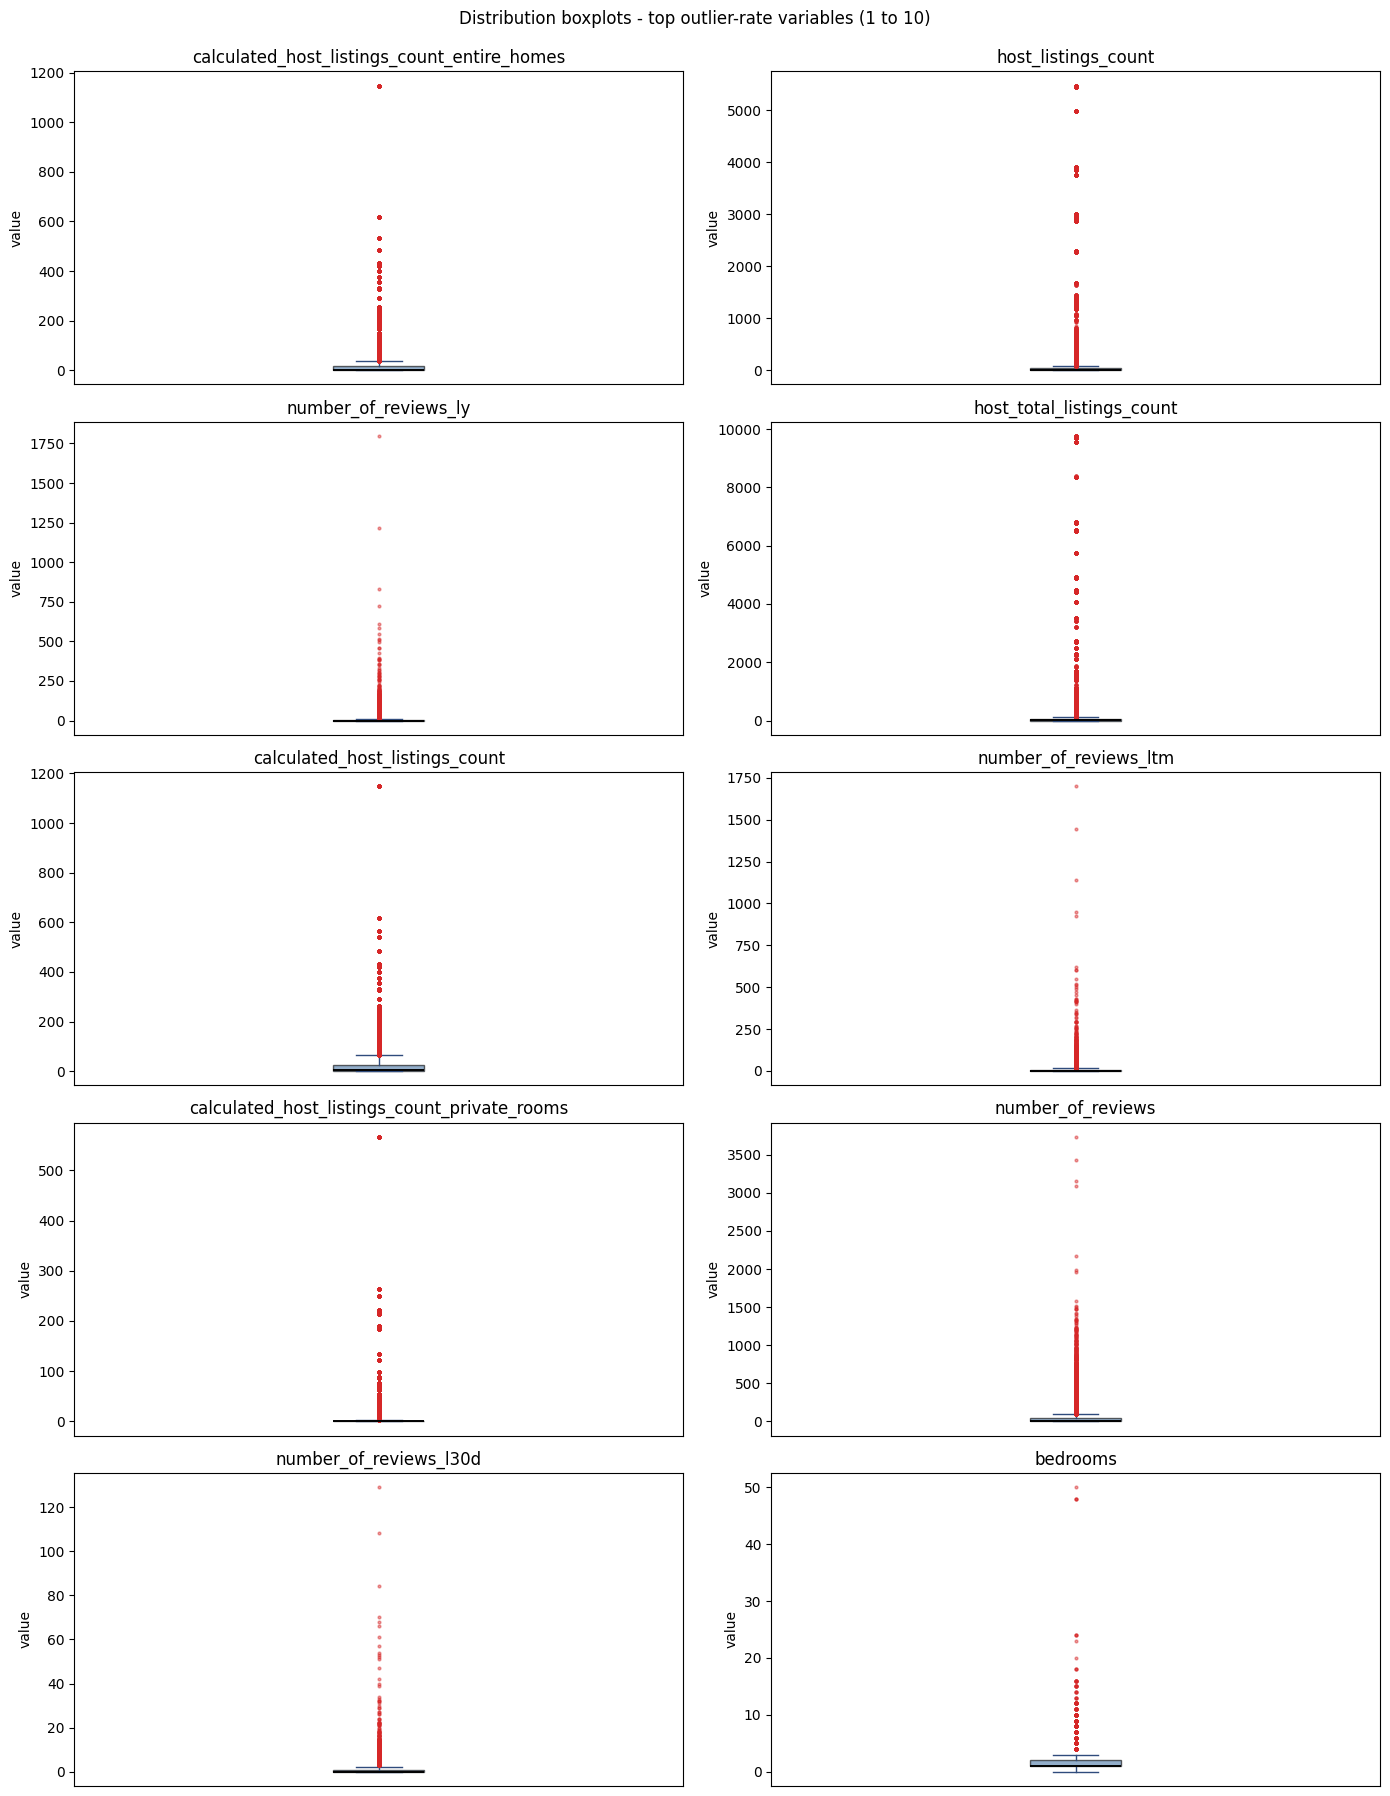

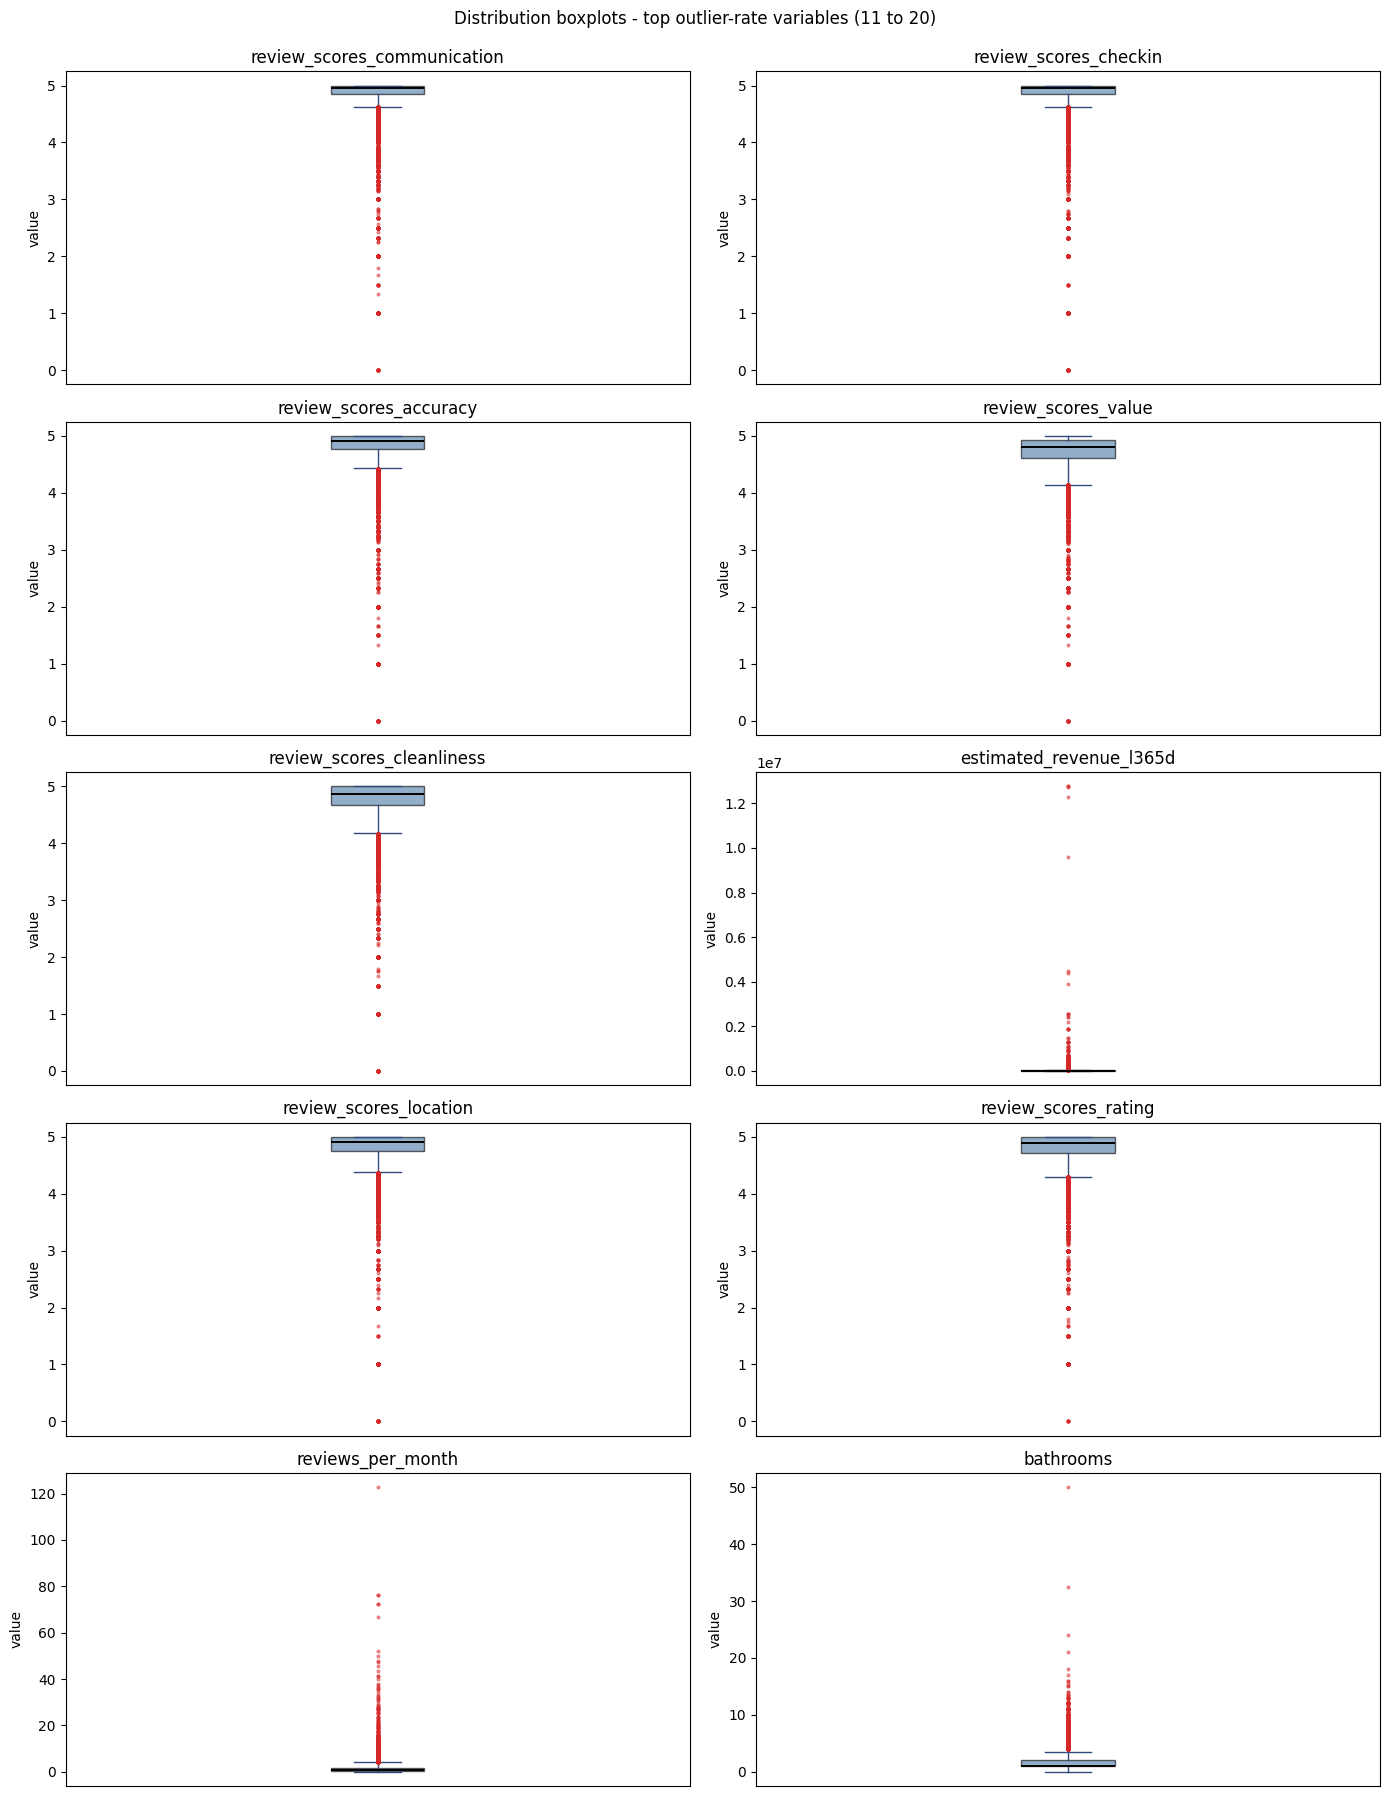

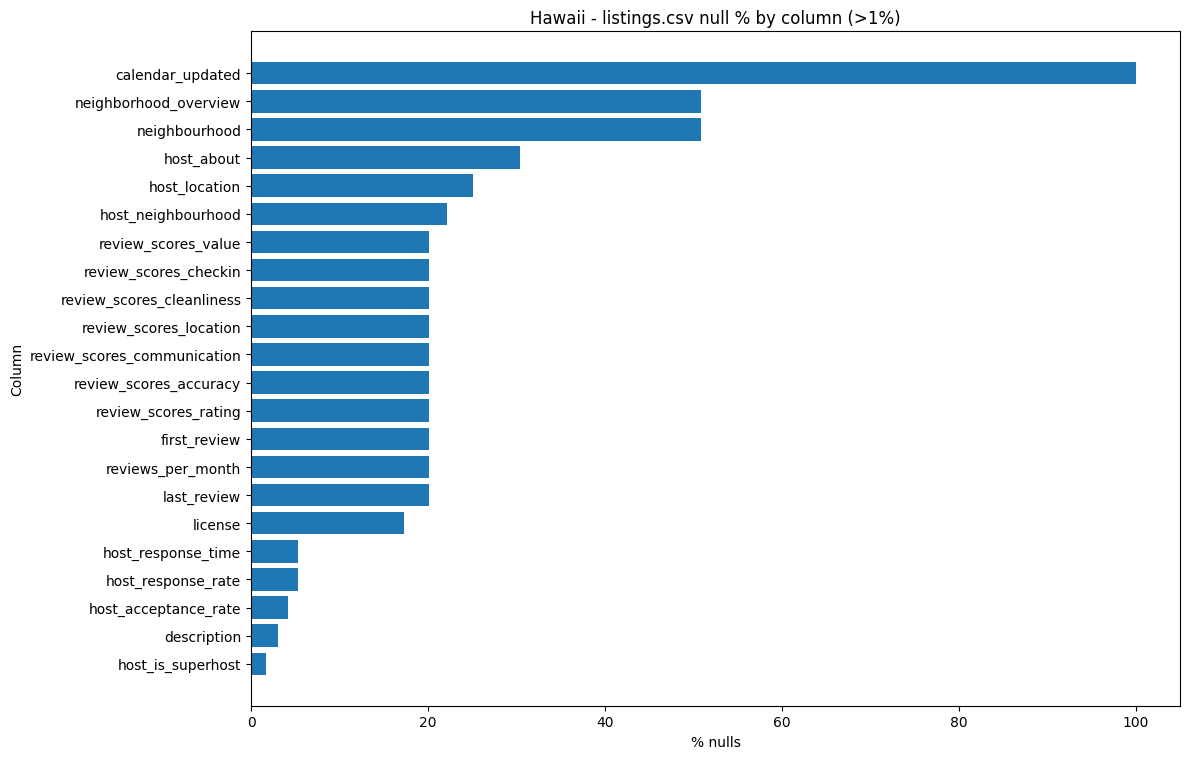

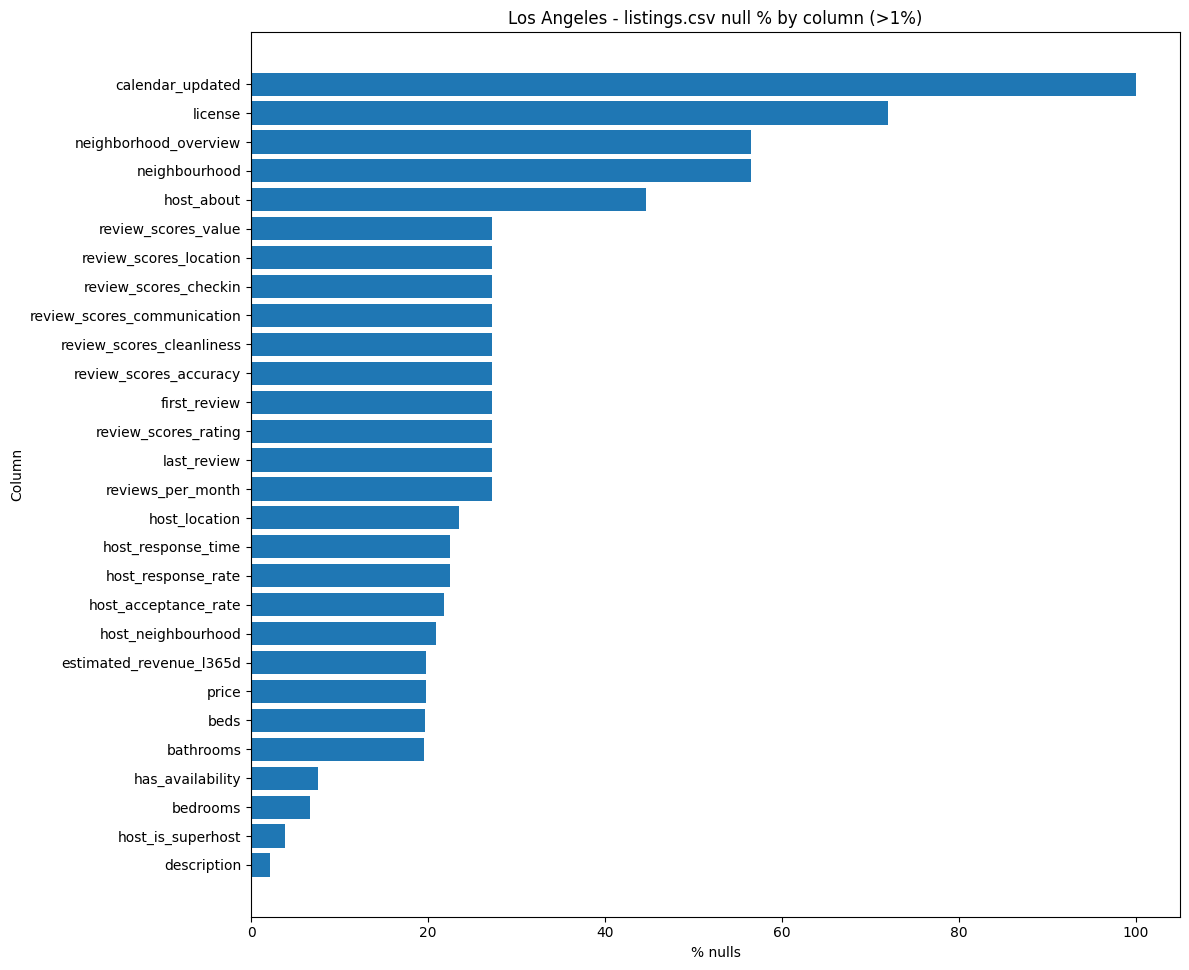

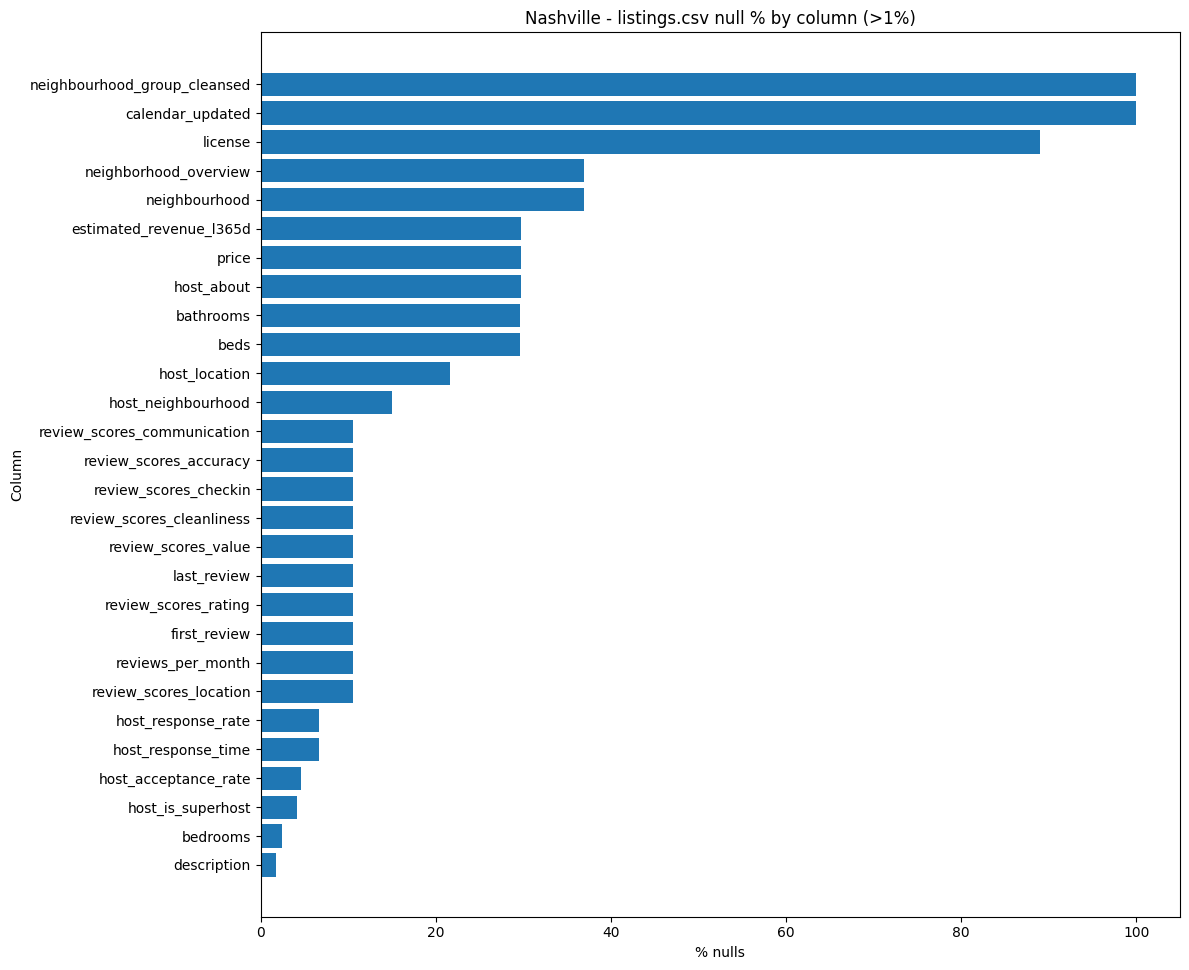

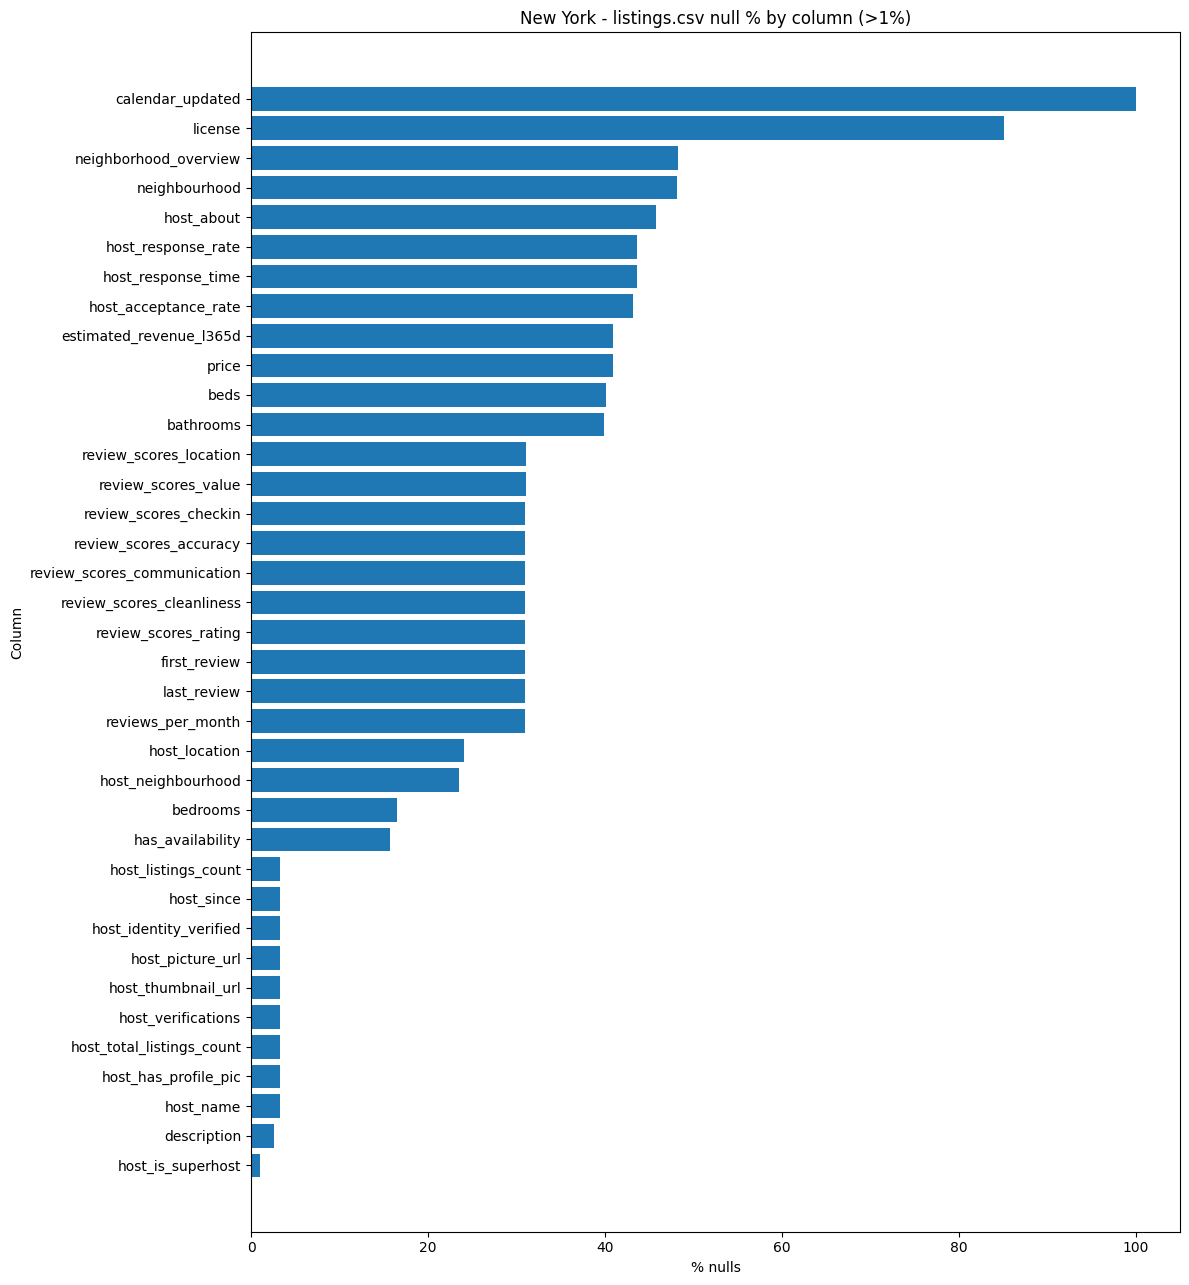

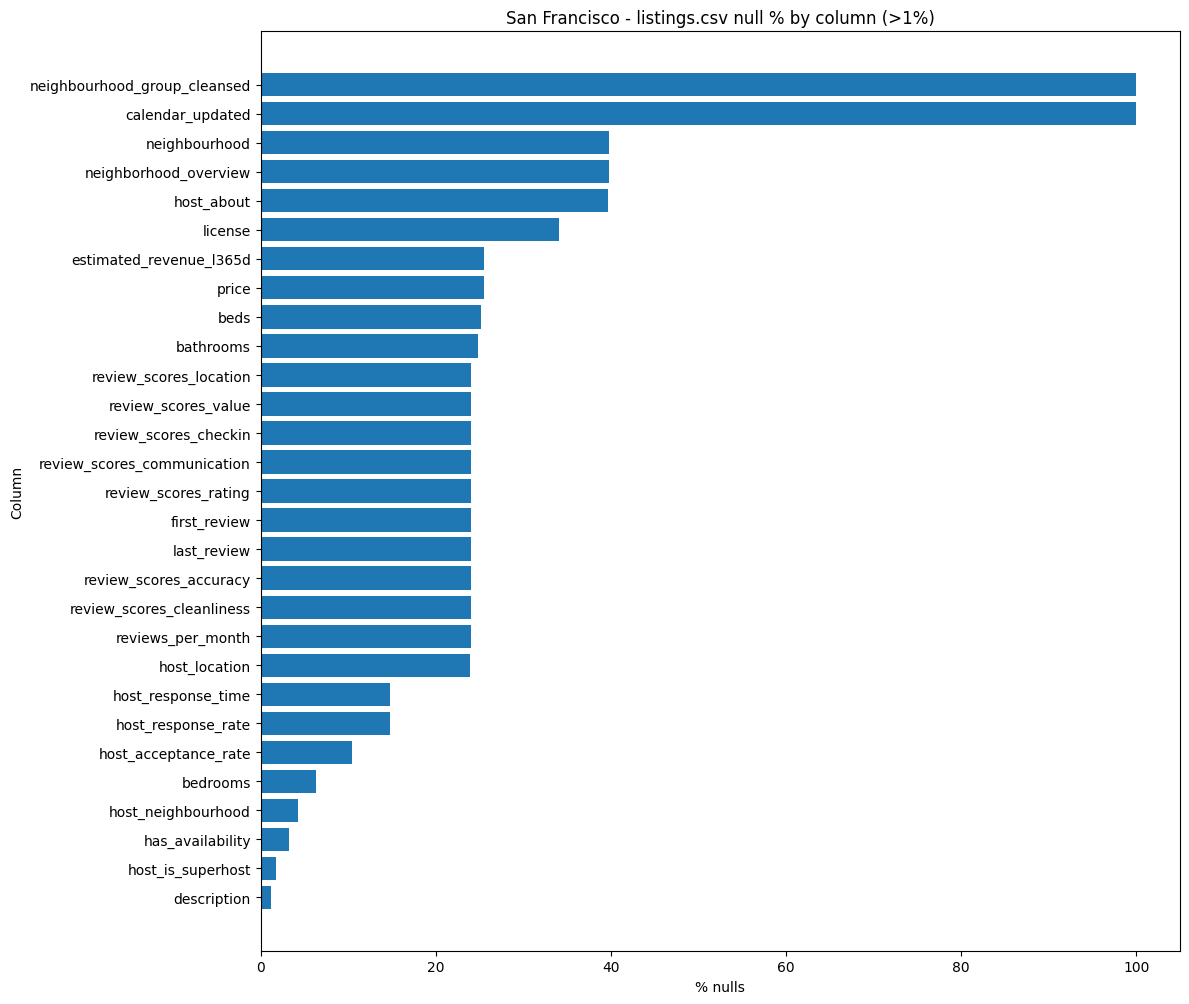

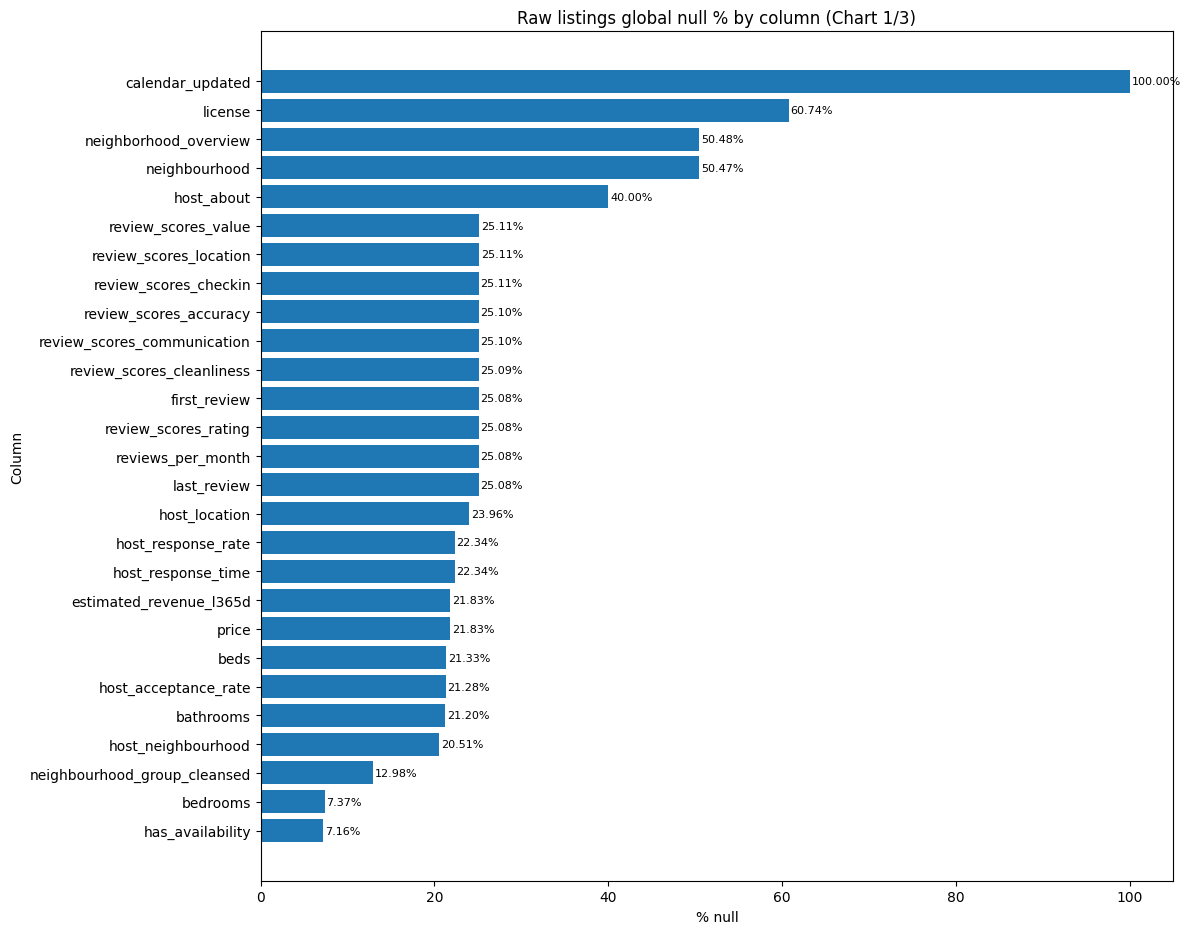

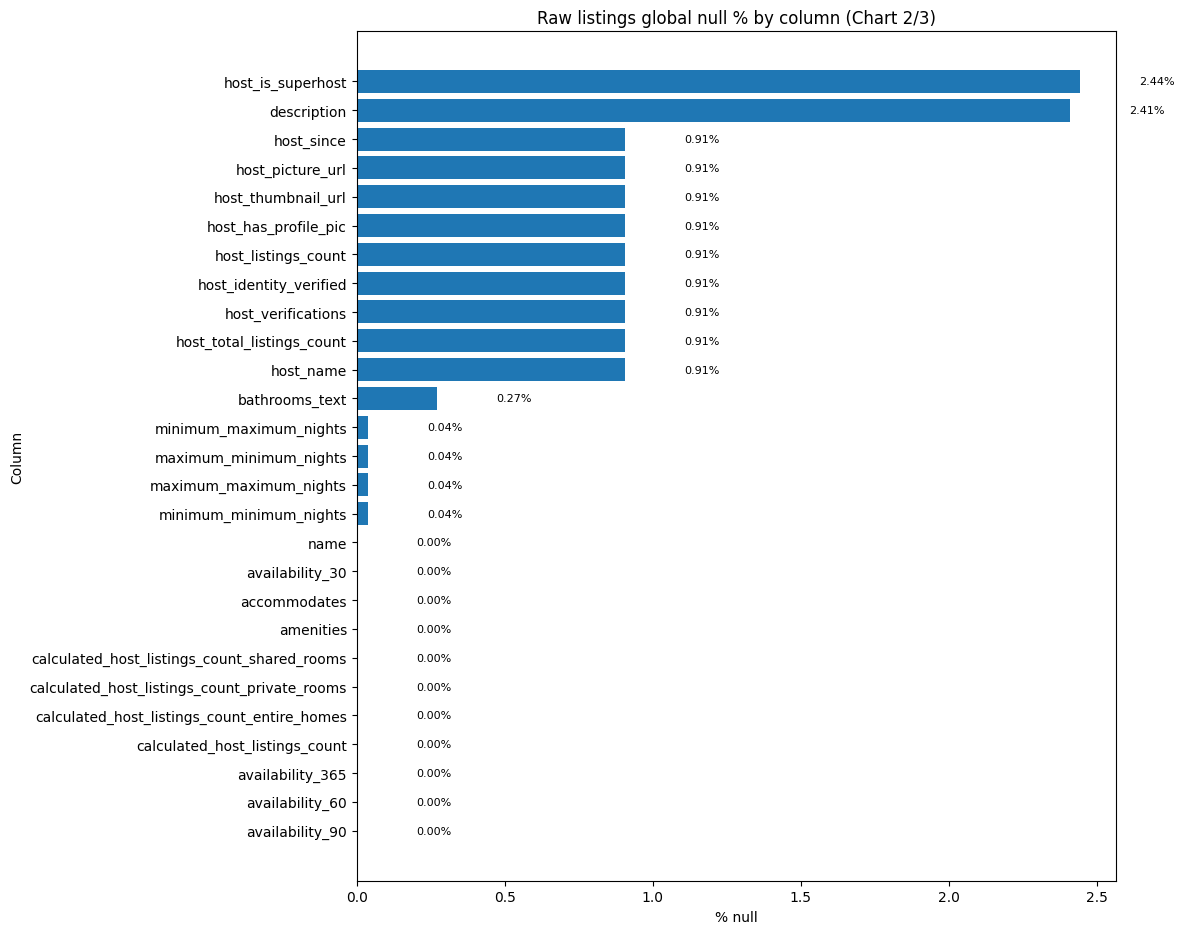

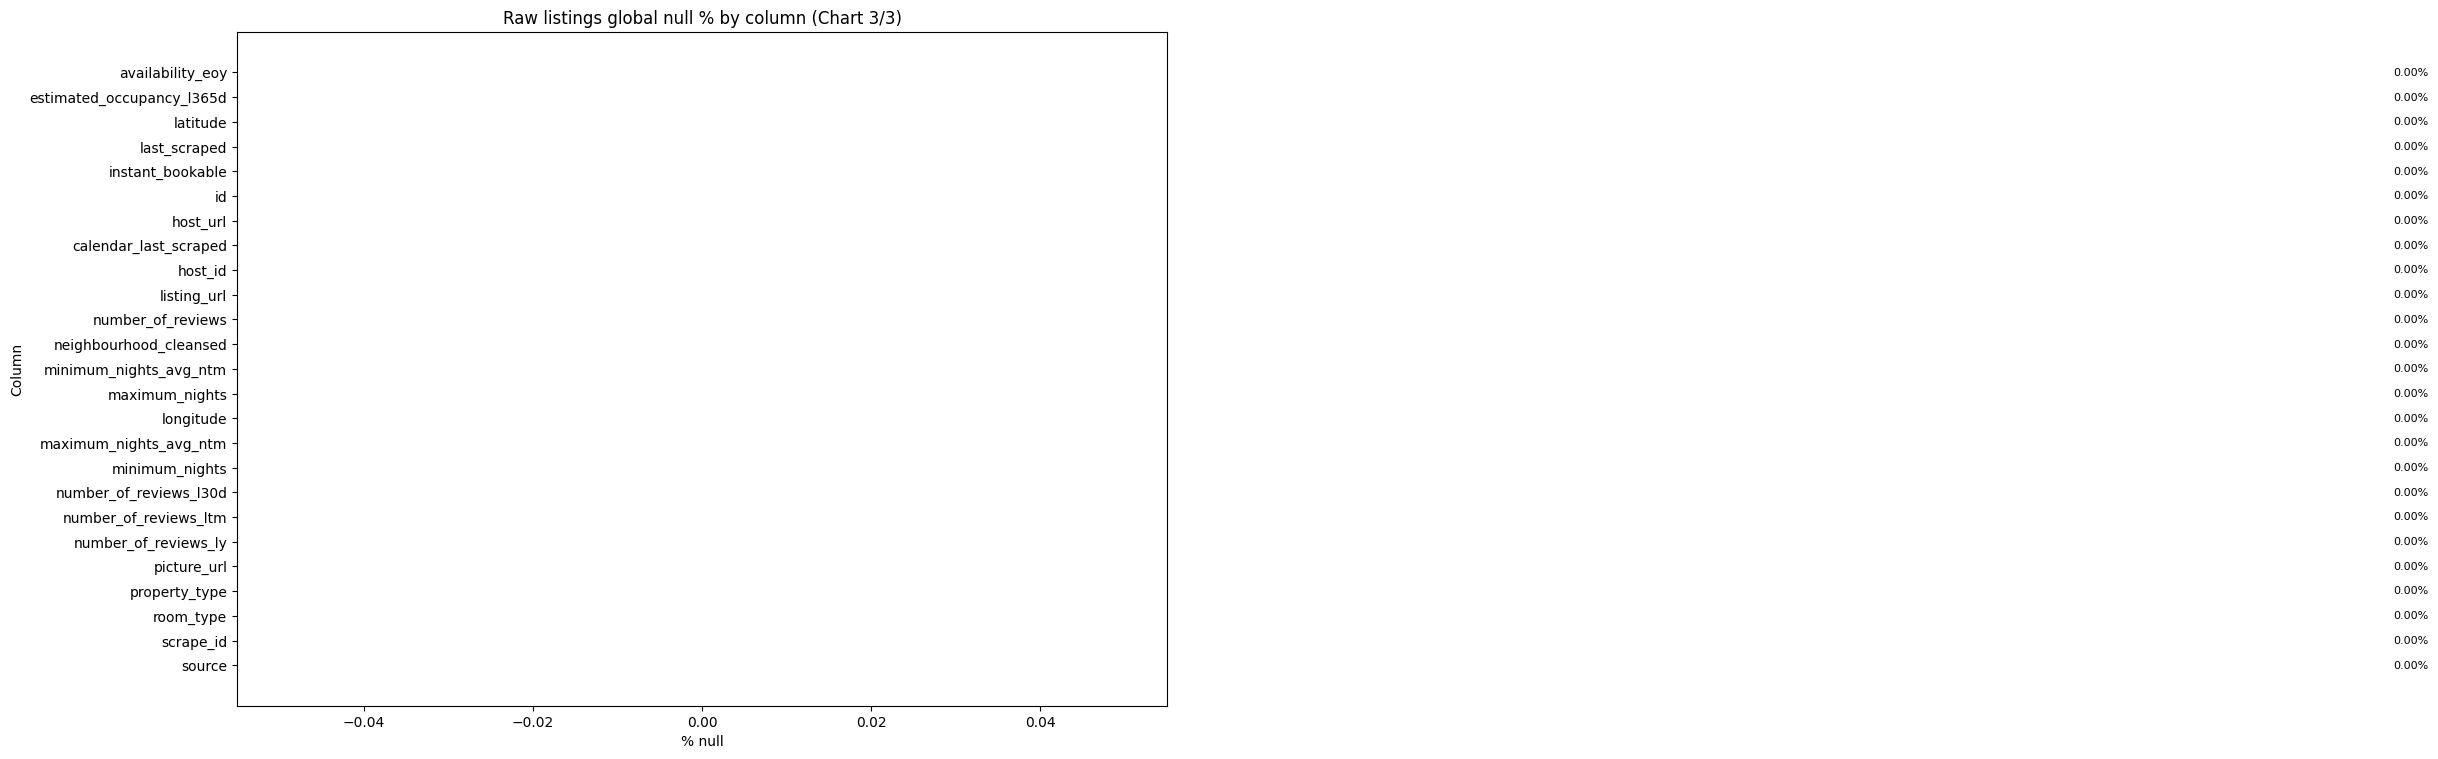

In [11]:
# Boxplots: top 20 variables by outlier rate
import math
import numpy as np
import pandas as pd
from IPython.display import display
from IPython import get_ipython

# Force inline rendering for this cell
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

raw_listing_frames = []
for city_dir in city_dirs:
    listings_file = city_dir / "listings.csv"
    if not listings_file.exists():
        continue
    city_df = pd.read_csv(listings_file, encoding="utf-8-sig", low_memory=False)
    city_df["City"] = city_dir.name
    raw_listing_frames.append(city_df)

if not raw_listing_frames:
    raise FileNotFoundError("No raw city listings.csv files found for outlier EDA.")

df_top = pd.concat(raw_listing_frames, ignore_index=True, sort=False)
num_df = df_top.select_dtypes(include=[np.number]).copy()
rows = len(df_top)

# Recompute outlier rate so this section is self-contained.
outlier_rows = []
for col in num_df.columns:
    s = pd.to_numeric(num_df[col], errors="coerce").dropna()
    if len(s) < 5:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        outlier_count = 0
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = int(((s < lower) | (s > upper)).sum())

    outlier_rate = (outlier_count / rows * 100) if rows else 0
    outlier_rows.append({"column": col, "outlier_rate": outlier_rate})

outlier_rate_df = pd.DataFrame(outlier_rows).sort_values("outlier_rate", ascending=False)
top20_cols = outlier_rate_df.head(20)["column"].tolist()

print("Top 20 variables by outlier rate:")
print(top20_cols)

# Plot in pages of 10 boxplots each (5x2) for readability.
cols_per_page = 10
for page_start in range(0, len(top20_cols), cols_per_page):
    cols_chunk = top20_cols[page_start:page_start + cols_per_page]
    fig, axes = plt.subplots(5, 2, figsize=(14, 18))
    axes = axes.flatten()

    for i, col in enumerate(cols_chunk):
        s = pd.to_numeric(df_top[col], errors="coerce").dropna()
        axes[i].boxplot(
            s,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor="#4c78a8", alpha=0.6),
            medianprops=dict(color="black", linewidth=1.4),
            whiskerprops=dict(color="#2f4b7c"),
            capprops=dict(color="#2f4b7c"),
            flierprops=dict(marker="o", markersize=2, markerfacecolor="#d62728", markeredgecolor="#d62728", alpha=0.45),
        )
        axes[i].set_title(col)
        axes[i].set_ylabel("value")
        axes[i].set_xticks([])

    # Hide empty subplot slots if chunk < 10
    for j in range(len(cols_chunk), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Distribution boxplots - top outlier-rate variables ({page_start + 1} to {page_start + len(cols_chunk)})", y=0.995)
    plt.tight_layout()
    display(fig)
    plt.close(fig)